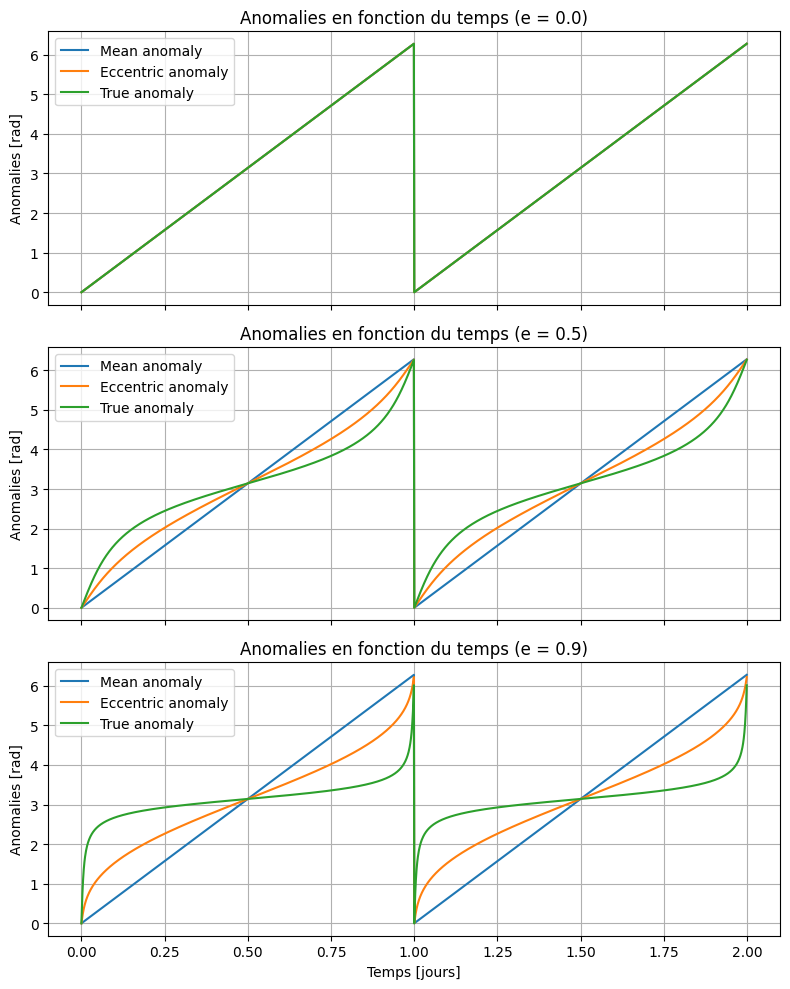

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Internal_constants import *

# ----------------------------------------------------------
# Fonction vectorisée pour calculer anomalies orbitales 
# ----------------------------------------------------------
def compute_anomalies(e, t_revolution, t_init, t_end, step):
    """
    Calcule les anomalies moyenne (M), excentrique (E) et vraie (v)
    pour un satellite d'excentricité e sur un intervalle de temps donné.

    Paramètres :
        e  : excentricité (0 ≤ e < 1)
        t_revolution  : période orbitale
        t_init  : temps initial
        t_end  : temps final
        step  : pas de temps

    Retour :
        t (ndarray) : temps
        M (ndarray) : anomalies moyennes
        E (ndarray) : anomalies excentriques
        v (ndarray) : anomalies vraies
    """

    # ------------------------------------------------------
    # Tableau de temps
    # ------------------------------------------------------
    t = np.arange(t_init, t_end, step)

    # ------------------------------------------------------
    # Anomalie moyenne (M) vectorisée
    # M = n * (t - t0) ; n = 2*pi / t_revolution
    # ------------------------------------------------------
    M = np.mod((2 * PI / t_revolution) * (t - t_init), 2*PI)

    # ------------------------------------------------------
    # Initialisation de l'anomalie excentrique E
    # ------------------------------------------------------
    E = np.copy(M)  # E_0 = M

    # Si l'excentricité n'est pas nulle, on résout l'équation de Kepler : M = E - e*sin(E)
    # avec la méthode de Newton-Raphson
    # ------------------------------------------------------
    if e != 0:
        max_iter = 100        # nombre maximal d'itérations
        tol = 1e-12           # tolérance pour convergence
        for _ in range(max_iter):
            # Calcul de la fonction et de sa dérivée
            E_new = E - (E - e*np.sin(E) - M) / (1 - e*np.cos(E))

            # Vérification du critère de convergence
            if np.all(np.abs(E_new - E) < tol):
                E = E_new
                break

            E = E_new

    # ------------------------------------------------------
    # Anomalie vraie (v) vectorisée
    # ------------------------------------------------------
    v = 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))
    v = np.mod(v, 2*PI)  # restreindre dans [0, 2pi]

    return t, M, E, v

# ----------------------------------------------------------
# Simulation pour plusieurs excentricités
# ----------------------------------------------------------
ecc_values = [0.0, 0.5, 0.9]
results = {}

for e in ecc_values:
    results[e] = compute_anomalies(e, t_revolution=1, t_init=0, t_end=2, step=0.001)

# ----------------------------------------------------------
# Création de la figure avec 3 sous-plots
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for i, e in enumerate(ecc_values):
    t, M, E, v = results[e]
    axes[i].plot(t, M, label='Mean anomaly')
    axes[i].plot(t, E, label='Eccentric anomaly')
    axes[i].plot(t, v, label='True anomaly')
    axes[i].set_title(f'Anomalies en fonction du temps (e = {e})')
    axes[i].set_ylabel('Anomalies [rad]')
    axes[i].legend()
    axes[i].grid(True)

axes[2].set_xlabel('Temps [jours]')

plt.tight_layout()
plt.show()
